<a href="https://colab.research.google.com/github/SalvarezJ/Crib-Sentry/blob/main/notebooks/01_first_working_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Crib Sentry: First Working Demo**

In [1]:
!nvidia-smi

Fri Oct  2 03:23:43 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 10.6 MB/s eta 0:00:00


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.

image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 10.0ms
Speed: 89.2ms preprocess, 10.0ms inference, 35.1ms postprocess per image at shape (1, 3, 640, 480)


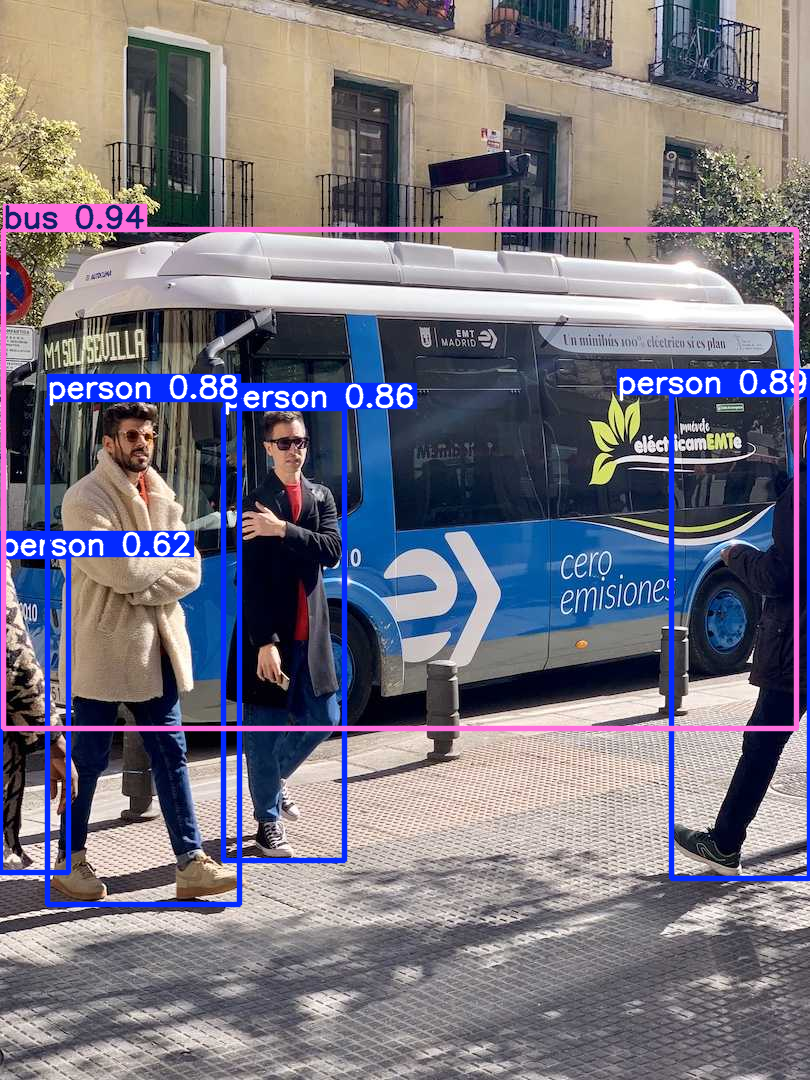

In [3]:
from ultralytics import YOLO

model = YOLO('yolo11n.pt')   # pretrained on COCO, 'n' is the smallest version

results = model('https://ultralytics.com/images/bus.jpg')
results[0].show()            # shows the image with boxes drawn on it

In [4]:
!pip install roboflow

from roboflow import Roboflow
from google.colab import userdata

rf = Roboflow(api_key=userdata.get('ROBOFLOW_API_KEY'))
project = rf.workspace("test-1caua").project("baby-in-crib")
dataset = project.version(1).download("yolov11")

print(dataset.location)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.6/333.6 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 88.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 6.8 MB/s eta 0:00:00
  Attempting uninstall: typer
    Found existing installation: typer 0.27.2
    Uninstalling typer-0.27.2:
      Successfully uninstalled typer-0.27.2
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Baby-in-Crib-1 in yolov11:: 100%|██████████| 496/496 [00:00<00:00, 6980.09it/s]

/content/Baby-in-Crib-1



0: 640x640 1 bed, 9.8ms
1: 640x640 1 person, 9.8ms
2: 640x640 1 person, 1 bed, 9.8ms
3: 640x640 1 person, 9.8ms
4: 640x640 1 person, 9.8ms
5: 640x640 1 person, 9.8ms
6: 640x640 1 person, 1 bed, 9.8ms
7: 640x640 (no detections), 9.8ms
Speed: 1.1ms preprocess, 9.8ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)


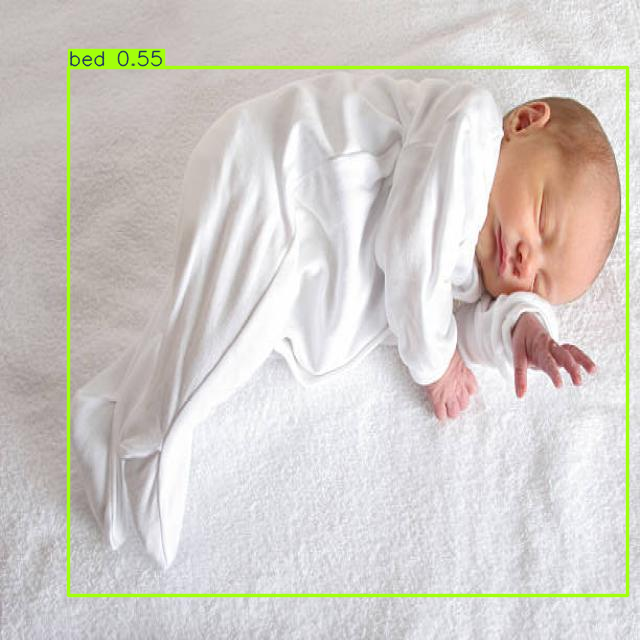

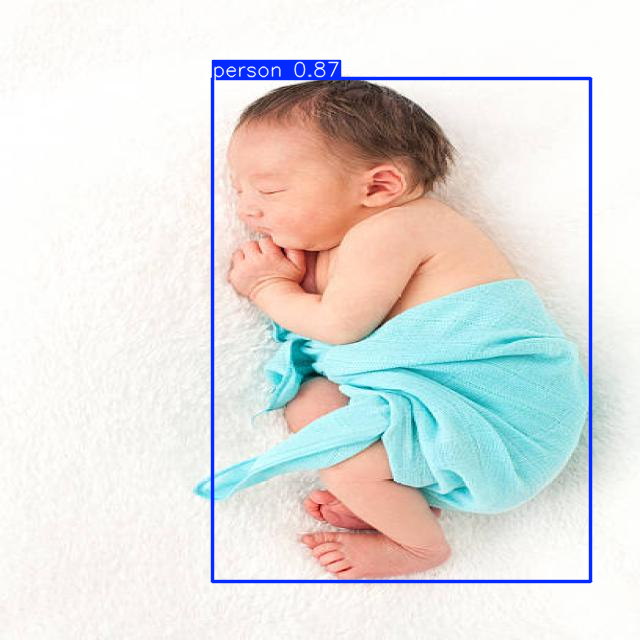

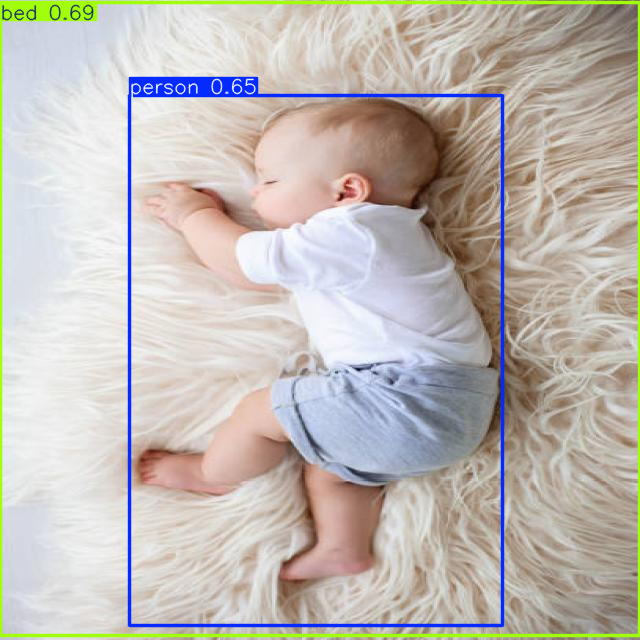

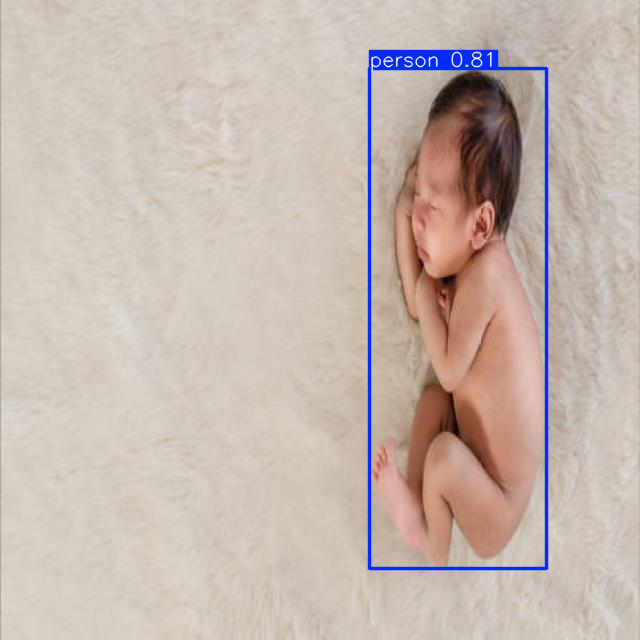

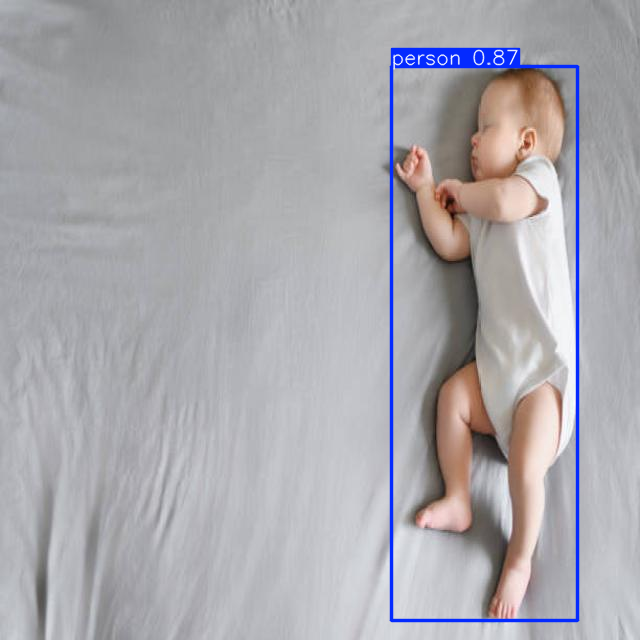

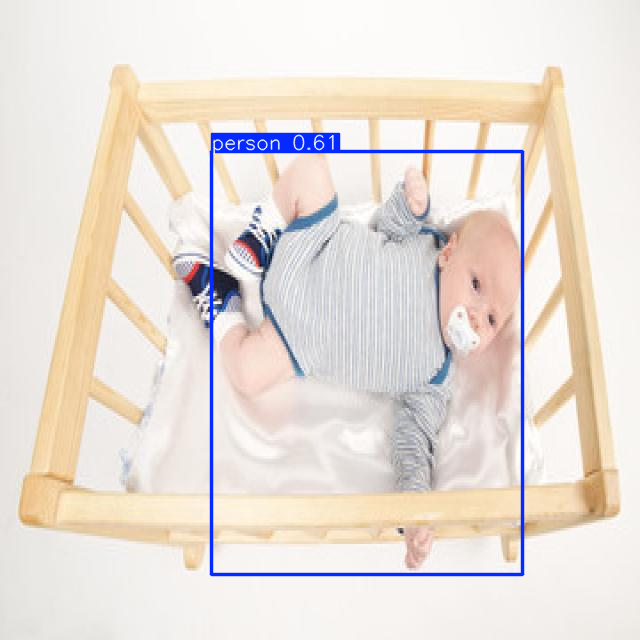

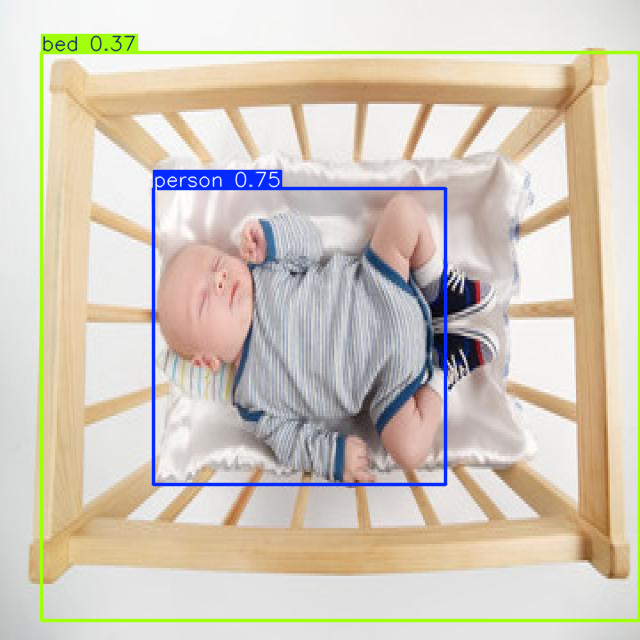

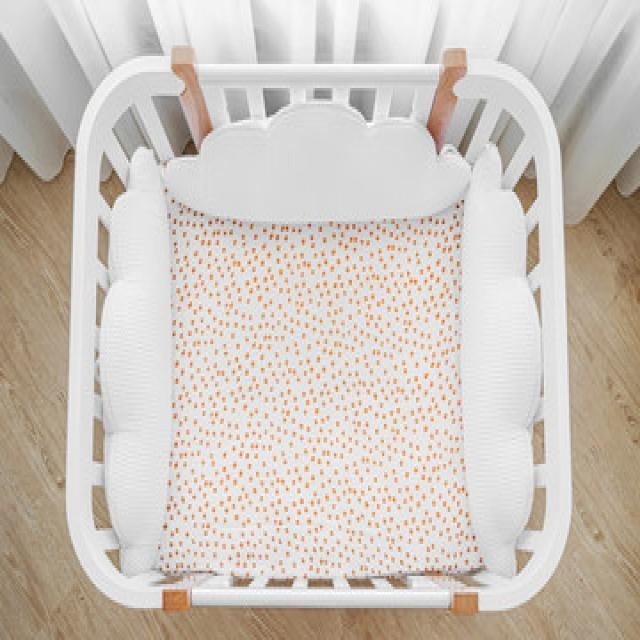

In [5]:
import glob

images = sorted(glob.glob(dataset.location + '/test/images/*'))[:8]

results = model(images)
for r in results:
    r.show()

## Test set check
Counts which classes appear in each of the 24 test images.

In [6]:
import glob

label_files = sorted(glob.glob(dataset.location + '/test/labels/*.txt'))

counts = {}
for path in label_files:
    classes = set()
    for line in open(path):
        if line.strip():
            classes.add(int(line.split()[0]))
    key = tuple(sorted(classes))
    counts[key] = counts.get(key, 0) + 1

print(open(dataset.location + '/data.yaml').read())
print('Test images:', len(label_files))
for key, n in counts.items():
    print(key, n)

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 2
names: ['Child', 'Crib']

roboflow:
  workspace: test-1caua
  project: baby-in-crib
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/test-1caua/baby-in-crib/dataset/1
Test images: 24
(0,) 8
(0, 1) 8
(1,) 8
